# Aprendizaje Supervisado Kaggle Competition


### Requerimientos del práctico

1. Realizar un análisis exploratorio de datos, y utilizar lo aprendido para generar su mejor modelo.

2. Superar el puntaje del baseline público en la competencia kaggle.

3. Usar al menos 3 modelos distintos al del árbol de decisión que se explora como baseline, se puede explorar el árbol de decisión y explorar otros modelo.

4. Entregar una notebook con el análisis exploratorio de datos y el código con los 3 mejores modelos entregados.

Deben:

- Explorar los datos y aprender de ellos.

- Probar diferentes modelos y ver cuáles ajustan mejor dado los datos.

- Para esta competencia se elige como métrica el balanced_accuracy_score. Discutir, analizar y justificar porque es necesaria está métrica para este problema.

- Obtener una métrica mejor que la que se presenta en este ejemplo.

- Tratar de obtener un score lo más alto posible!
- Discutir la elección de modelo.

El análisis exploratorio y el preprocesamiento de los datos queda a libertad de cada grupo y no deben quedarse con este simple ejemplo.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, classification_report, precision_score, accuracy_score, balanced_accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
sns.set(style="whitegrid")

### Dataset

Cargamos los datos de entrenamiento que vamos a utilizar para generar el modelo.

**Atributos del dataset**

- Id: identificador único de la imagen.
- Clase: etiqueta objetivo: ccb (cara con barbijo) o csb (cara sin barbijo).
- bb_width: ancho del recorte de la cara (bounding box).
- bb_height: alto de recorte de la cara.
- ch_RGB: promedio del histograma de los tres canales de color RGB.
- 1097, 595, ...: vector de características numéricas extraído por la red convolucional.

In [37]:
import pandas as pd

url_train = "https://raw.githubusercontent.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_train-labeled2.csv"
url_test = "https://raw.githubusercontent.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_test2.csv"

train_df = pd.read_csv(url_train, sep=';')
test_df = pd.read_csv(url_test, sep=',')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print()
train_df.info()


Train shape: (1884, 438)
Test shape: (524, 438)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Columns: 438 entries, id to 198
dtypes: float64(434), int64(3), object(1)
memory usage: 6.3+ MB


Shapes: (1884, 438) para train y (524, 438) para test.

In [38]:
#Primeras filas
train_df.head()

,id,clase,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,ccb,118,167,126.002029,0.171342,0.254909,1.729943,0.872499,0.645055,...,0.000246,0.081324,0.391930,0.247319,0.033110,0.394890,0.204616,1.668020,0.052727,0.302152
1,2,ccb,286,396,152.522842,0.172407,0.217375,2.900968,0.421334,0.270867,...,0.056044,0.059036,0.123057,0.462978,0.037138,0.658777,0.172517,0.507375,0.274298,0.648528
2,3,csb,123,167,93.290398,0.139690,0.759909,0.081340,0.325830,0.018619,...,0.021488,0.350511,0.165781,0.114810,0.154125,0.193874,0.393903,0.170703,0.099427,0.344505
3,4,ccb,64,72,87.209783,0.118689,0.256016,2.980141,0.264635,0.740855,...,0.060695,0.216600,0.818982,0.394102,0.029060,0.734705,0.006737,0.484864,0.236771,0.168539
4,5,csb,368,410,96.280184,0.065417,0.556244,0.030811,0.380362,0.092278,...,0.063842,0.353856,0.149680,0.367398,0.082724,0.120532,0.548468,0.605817,0.040803,0.061662


Cada fila representa una imagen de una cara, ya procesada por la ResNet. Las columnas bb_width, bb_height y ch_RGB son features interpretables, mientras que el resto son las 434 activaciones extraídas por la red convolucional, no tienen un significado interpretable individualmente, pero capturan patrones visuales aprendidos por el modelo.

In [39]:
resnet_cols = [c for c in train_df.columns if c not in ['id', 'clase', 'bb_width', 'bb_height', 'ch_RGB']]

In [40]:
# Nulos en train y test
print("Nulos en train:", train_df.isnull().sum().sum())
print("Nulos en test:", test_df.isnull().sum().sum())
print("\nNulos por columna en test (solo las que tienen):")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Nulos en train: 0
Nulos en test: 524

Nulos por columna en test (solo las que tienen):
clase    524
dtype: int64


El conjunto de entrenamiento no tiene ningún valor nulo. Clase es la variable objetivo que debemos predecir, por lo que en el conjunto test viene vacía a propósito. Las demás features están completas en ambos conjuntos, no es necesario imputar.

In [41]:
# Duplicados
print("Filas duplicadas en train:", train_df.duplicated().sum())
print("IDs duplicados en train:", train_df['id'].duplicated().sum())
print("IDs duplicados en test:", test_df['id'].duplicated().sum())

Filas duplicadas en train: 0
IDs duplicados en train: 0
IDs duplicados en test: 0


No se encontraron filas ni IDs duplicados en train ni test.

In [42]:
# Estadísticas descriptivas
train_df.describe()


,id,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,1448,...,1152,1428,182,488,1369,582,570,2022,1966,198
count,1884.000000,1884.000000,1884.00000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,...,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000
mean,942.500000,101.909236,133.47983,114.109534,0.168035,0.400830,1.690452,0.296696,0.445435,0.442737,...,0.066285,0.171946,0.215352,0.416790,0.085017,0.320012,0.318657,0.693318,0.223473,0.250213
std,544.008272,91.933372,119.15816,30.696614,0.126249,0.273933,1.219991,0.213530,0.406341,0.284700,...,0.069526,0.179459,0.209379,0.278408,0.086755,0.221458,0.231352,0.457887,0.116369,0.161713
min,1.000000,11.000000,12.00000,40.301282,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000246,0.000000,0.000648,0.000000,0.001931,0.007359,0.000000
25%,471.750000,48.750000,59.00000,92.309942,0.075003,0.199049,0.547147,0.135446,0.115591,0.237259,...,0.015967,0.058051,0.064764,0.194096,0.023932,0.152957,0.141901,0.331458,0.133532,0.129353
50%,942.500000,71.000000,88.00000,109.841245,0.143056,0.336917,1.631053,0.251868,0.342227,0.381312,...,0.045157,0.119384,0.147675,0.360841,0.057883,0.271596,0.274714,0.618690,0.214287,0.219952
75%,1413.250000,120.000000,167.00000,134.545488,0.234480,0.541367,2.653032,0.400949,0.644068,0.569638,...,0.095316,0.217514,0.307282,0.593489,0.117845,0.435103,0.450637,0.946997,0.296023,0.336383
max,1884.000000,1296.000000,1070.00000,202.392985,0.991374,1.821444,5.263674,1.397370,2.541877,2.500119,...,0.538534,1.363758,1.493638,1.545518,0.859438,1.943598,1.753040,3.450385,0.627220,1.135739


Se observa que bb_width y bb_height tienen rangos muy amplios (de 11 a 1296 y  de 12 a 1070), lo que indica que hay tamaño dispares según la resolución del video/frame original. Las features de la ResNet están en escalas más chicas y homogéneas entre sí.

In [43]:
train_df[['bb_width', 'bb_height', 'ch_RGB']].describe()

,bb_width,bb_height,ch_RGB
count,1884.000000,1884.00000,1884.000000
mean,101.909236,133.47983,114.109534
std,91.933372,119.15816,30.696614
min,11.000000,12.00000,40.301282
25%,48.750000,59.00000,92.309942
50%,71.000000,88.00000,109.841245
75%,120.000000,167.00000,134.545488
max,1296.000000,1070.00000,202.392985


Al observar las columnas, se nota una diferencia de escalas entre columnas, ch_RGB tiene un rango más acotado comparado con el tamaño de bounding box, que varía mucho más (hasta 1296). Con esto se puede estandarizar más adelante.

clase
ccb    1436
csb     448
Name: count, dtype: int64

ccb: 76.2% | csb: 23.8%


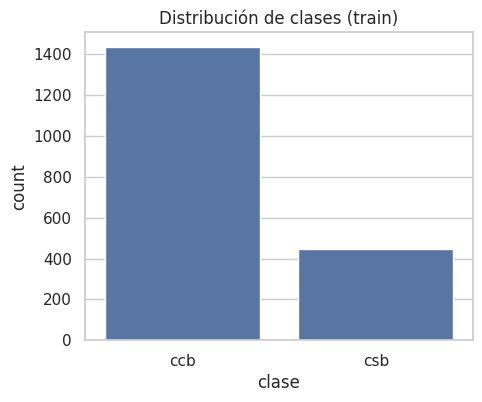

In [44]:
#Distribución de la variable objetivo (clase)
counts = train_df['clase'].value_counts()
print(counts)
print(f"\nccb: {counts['ccb']/len(train_df)*100:.1f}% | csb: {counts['csb']/len(train_df)*100:.1f}%")

plt.figure(figsize=(5,4))
sns.countplot(data=train_df, x='clase')
plt.title('Distribución de clases (train)')
plt.show()

La clase ccb (con barbijo) representa el 76,2% de los datos, mientras que csb (sin barbijo) solo el 23,8%. El modelo que prediga siempre ccb obtendría 76% de accuracy sin haber aprendido nada útil, mientras que el balanced accuracy promedia el recall de ambas clases por separado.

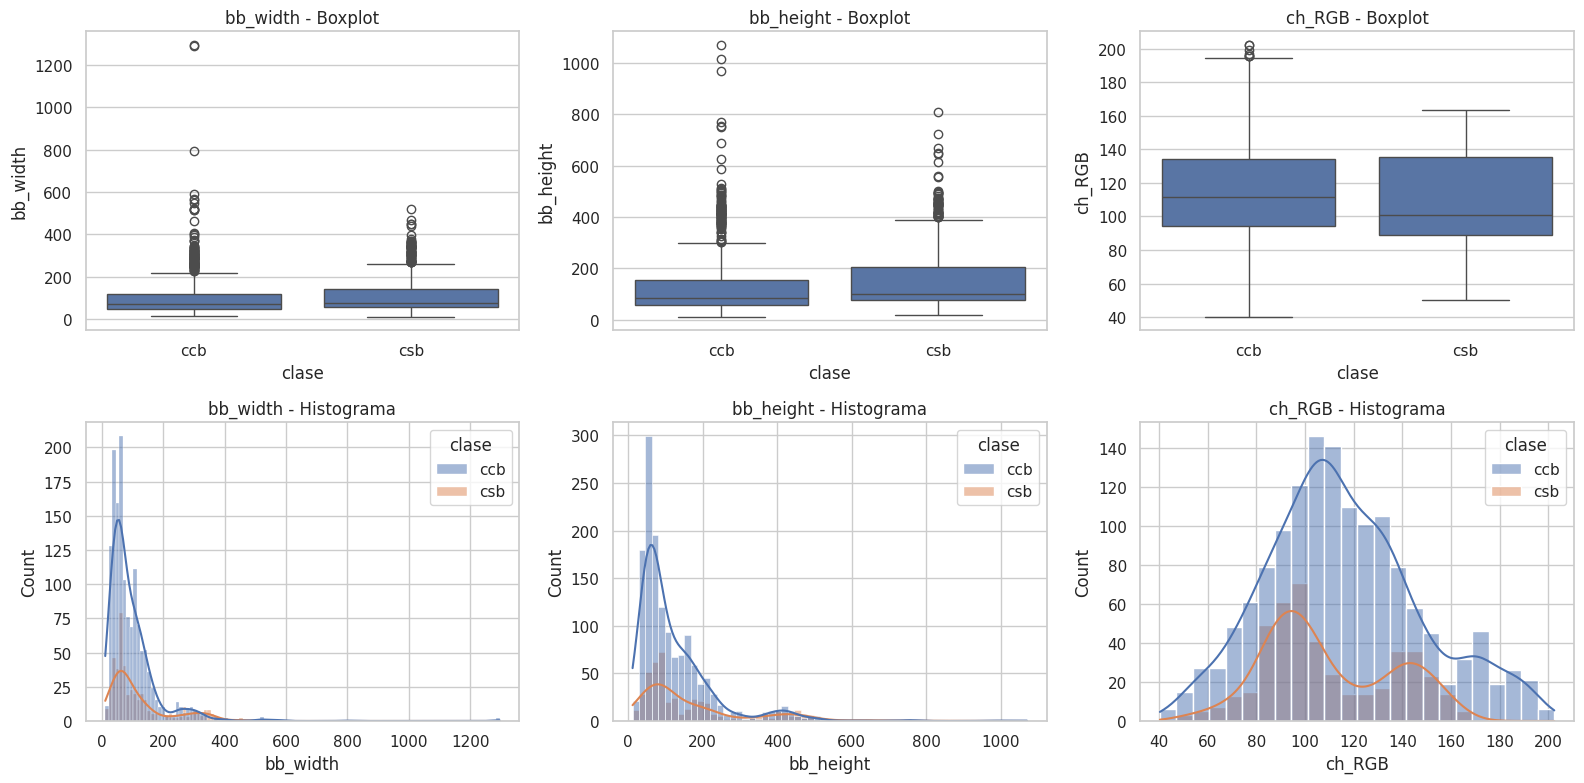

In [45]:
# Distribución de features por clase

features_simples = ['bb_width', 'bb_height', 'ch_RGB']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(features_simples):
    sns.boxplot(data=train_df, x='clase', y=col, ax=axes[0,i])
    axes[0,i].set_title(f'{col} - Boxplot')

    sns.histplot(data=train_df, x=col, hue='clase', kde=True, ax=axes[1,i])
    axes[1,i].set_title(f'{col} - Histograma')
plt.tight_layout()
plt.show()

Tanto en bb_width como en bb_height, la clase csb presenta medianas levemente más altas que ccb, aunque las cajas se superponen bastante y ambas clases tienen colas largas de valores atípicos.
En ch_RGB las distribuciones de ambas clases son idénticas, por lo que el color promedio parece no discriminar bien entre tener o no tener barbijo.

Los histogramas demuestran que se ve una superposición entre ccb y csb en las 3 features, con la clases ccb dominando por ser mayoritaria.



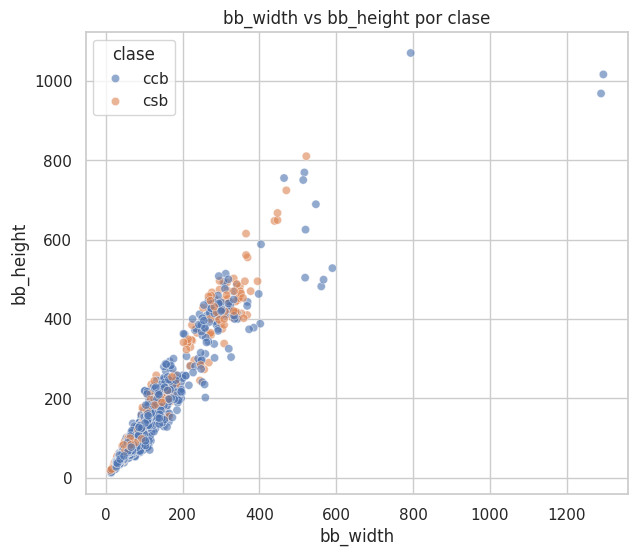

In [46]:
#Relación entre bounding box
plt.figure(figsize=(7,6))
sns.scatterplot(data=train_df, x='bb_width', y='bb_height', hue='clase', alpha=0.6)
plt.title('bb_width vs bb_height por clase')
plt.show()

Existe una relación lineal entre bb_width y bb_height, a mayor ancho, mayor alto del recorte como es esperable en proporciones faciales. No se observa una separación clara entre clases, los puntos están entremezclados.

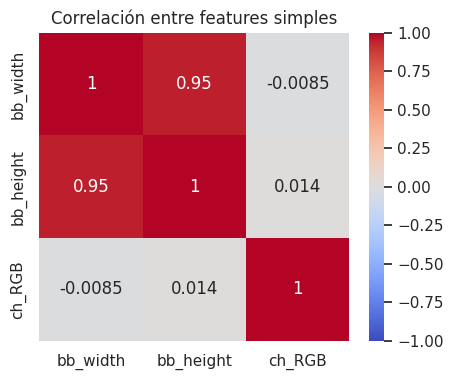

In [47]:
#Correlación entre features simple
plt.figure(figsize=(5,4))
sns.heatmap(train_df[features_simples].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre features simples')
plt.show()

bb_width y bb_height están correlacionados entre sí, ambas aportan la misma información. Podría considerarse combinarlas en una sola feature. ch_RGB no tiene correlación con ninguna de las dos, es una feature independiente del tamaño.

Features con menor varianza:
273     0.002161
1379    0.004530
1152    0.004834
1200    0.005330
1138    0.006626
748     0.007087
1369    0.007526
1976    0.008188
1463    0.008443
1823    0.008900
dtype: float64


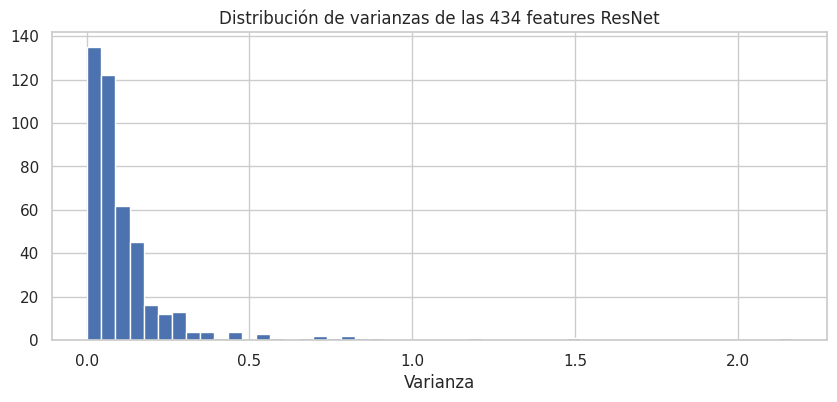

In [48]:
#Análisis de las features de la ResNet
variances = train_df[resnet_cols].var().sort_values()
print("Features con menor varianza:")
print(variances.head(10))

plt.figure(figsize=(10,4))
plt.hist(variances, bins=50)
plt.title('Distribución de varianzas de las 434 features ResNet')
plt.xlabel('Varianza')
plt.show()

La gran mayoría de las 434 features de la ResNet tiene varianza muy baja, algunas superan la varianza 0.5. En una red neuronal se esperan que muchas neuronas respondan débilmente o de forma casi constante ante la mayoría de imágenes, mientras que pocas concentran la mayor parte de la variabilidad útil.

In [49]:
#Observamos la correlación alta entre pares
corr_matrix = train_df[resnet_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, idx, upper.loc[idx, col])
                    for col in upper.columns for idx in upper.index
                    if pd.notna(upper.loc[idx, col]) and upper.loc[idx, col] > 0.9]
print(f"Pares de features con correlación > 0.9: {len(high_corr_pairs)}")

Pares de features con correlación > 0.9: 0


No se encontraron pares de features con correlación mayor a 0.9. Esto indica que las features de la ResNet no son redundantes entre sí y cada una aporta información distinta. No se elimina columnas por multicolinealidad.

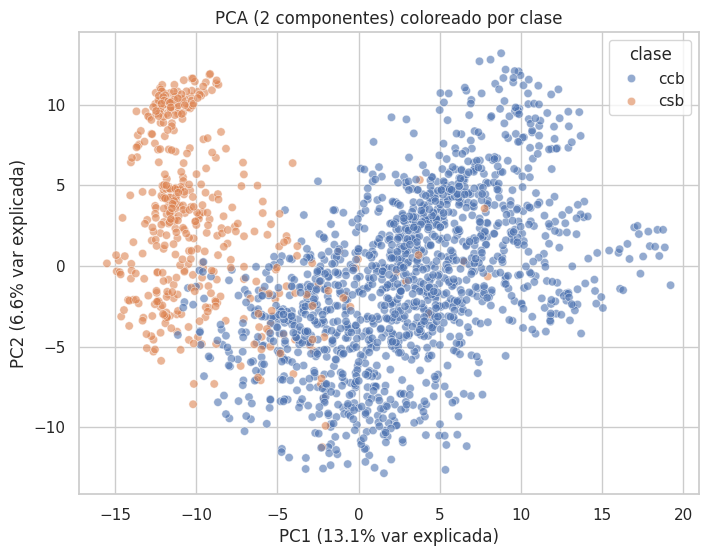

In [50]:
# Visualización en baja dimensión
X_vis = StandardScaler().fit_transform(train_df[resnet_cols])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=train_df['clase'], alpha=0.6)
plt.title('PCA (2 componentes) coloreado por clase')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var explicada)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var explicada)')
plt.show()

El PCA muestra una separación más marcada, gran parte de los puntos csb (naranja) se agrupan en una región bien diferenciada, mientras que ccb (azul) ocupa una región más amplia hacia la derecha y abajo. Hay una porción en la que ambos puntos se mezclan, por lo que la separación es parcial.

Los 2 componentes explican apenas el 19,7% de la varianza total.

In [51]:
#Comparación de distribución train vs test
comparacion = pd.DataFrame({
    'train_mean': train_df[features_simples].mean(),
    'test_mean': test_df[features_simples].mean(),
    'train_std': train_df[features_simples].std(),
    'test_std': test_df[features_simples].std(),
})
comparacion

,train_mean,test_mean,train_std,test_std
bb_width,101.909236,75.150763,91.933372,55.612066
bb_height,133.479830,93.467557,119.158160,71.920479
ch_RGB,114.109534,251.353361,30.696614,1902.441581


Se observa en ch_RGB la media (251.4) y el desvío estándar (1902) en test es más grande que la media (114.1) y el desvío estándar (30.7) train. Esto indica que el conjunto de test podría tener condiciones de iluminación o preprocesamiento distinto a los de train.

El Standarscaler debe ajustarse con los datos de train y luego aplicarse transform sobre test con esos mismo parámetros.

12     40632.314997
268    16240.642994
520      214.140035
299      213.935298
432      213.328710
374      212.757828
287      211.795685
102      211.550227
425      211.297877
118      209.769516
393      208.872716
503      208.048477
356      205.454971
319      204.199844
0        204.171544
Name: ch_RGB, dtype: float64


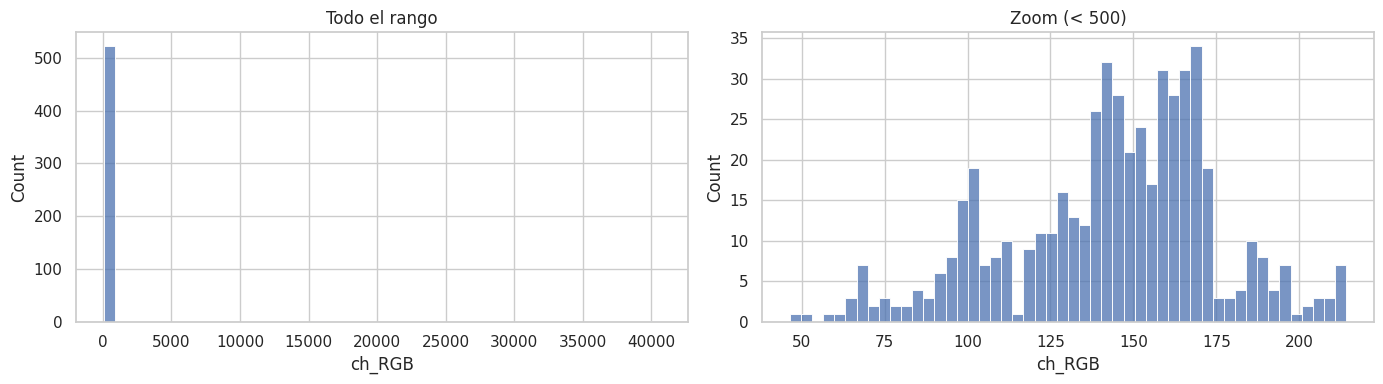

In [52]:
# Ver los valores más altos de ch_RGB en test
print(test_df['ch_RGB'].sort_values(ascending=False).head(15))


# Comparar rango normal (zoom) vs completo
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(test_df['ch_RGB'], bins=50, ax=axes[0])
axes[0].set_title('Todo el rango')

sns.histplot(test_df[test_df['ch_RGB'] < 500]['ch_RGB'], bins=50, ax=axes[1])
axes[1].set_title('Zoom (< 500)')
plt.tight_layout()
plt.show()

In [53]:
# 2 casos extremos
print(test_df.loc[[12, 268], ['id', 'ch_RGB', 'bb_width', 'bb_height']])

print(test_df[~test_df.index.isin([12, 268])]['ch_RGB'].describe())

      id        ch_RGB  bb_width  bb_height
12    13  40632.314997        25         32
268  269  16240.642994        16         22
count    522.000000
mean     143.364374
std       31.552993
min       46.409723
25%      126.031138
50%      146.744044
75%      164.416023
max      214.140035
Name: ch_RGB, dtype: float64


In [54]:
# Se recorta el valor ch_RGB al eprcentil 99 calculando sobre train
limite_superior = train_df['ch_RGB'].quantile(0.99)
print("Límite superior (percentil 99 de train):", limite_superior)

# Aplicamos el mismo clip a train y test
train_df['ch_RGB'] = train_df['ch_RGB'].clip(upper=limite_superior)
test_df['ch_RGB'] = test_df['ch_RGB'].clip(upper=limite_superior)

# Verificamos que los outliers de test ya no sean extremos
print(test_df.loc[[12, 268], 'ch_RGB'])


Límite superior (percentil 99 de train): 190.33510508219385
12     190.335105
268    190.335105
Name: ch_RGB, dtype: float64


El límite de recorte (percentil 99 de ch_RGB en train = 190.34) se calculó únicamente con datos de train, y luego se aplicó como techo tanto en train como en test. Esto tiene dos efectos distintos:

- En train: recorta 19 filas (el 1% superior por definición del percentil), no outliers reales. Este recorte es una consecuencia matemática de usar el percentil 99 del propio conjunto, no la corrección de una anomalía.
- En test: recorta 2 filas (ids 13 y 269) que sí eran outliers, con valores extremos de 16240.64 y 40632.31.



### Preprocesamiento

In [55]:
# Codificamos la variable objetivo: 1 = ccb (con barbijo), 0 = csb (sin barbijo)
train_df['clase'] = train_df['clase'].map({'ccb': 1, 'csb': 0})

# Separamos target e id
y = train_df['clase']
imagenID_train = train_df['id']
X = train_df.drop(['id', 'clase'], axis=1)

imagenID_test = test_df['id']
X_test = test_df.drop(['id', 'clase'], axis=1)  # clase está vacía en test, la sacamos

print("X:", X.shape, "| y:", y.shape, "| X_test:", X_test.shape)

X: (1884, 436) | y: (1884,) | X_test: (524, 436)


In [56]:
# Se elimina las features de varianza casi nula
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  # ajustable
X_reduced = selector.fit_transform(X)
X_test_reduced = selector.transform(X_test)

print("Columnas antes:", X.shape[1], "| después de sacar baja varianza:", X_reduced.shape[1])

Columnas antes: 436 | después de sacar baja varianza: 425


Para el escalado se utilizó StandarScaler, ajustando solo con train y aplicando igual a test para evirar data leakage.

In [57]:
# StandarScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

80/20 se forma estratificada, para que la proproción se mantenga en ambos subconjuntos.

In [58]:
# Split train/validación
x_train, x_val, y_train, y_val = train_test_split(
    X_scaled, y, train_size=0.8, random_state=8, stratify=y
)
print(x_train.shape, x_val.shape)

(1507, 425) (377, 425)


## Comparación de Modelos (SVM, Random Forest, XGBoost)



SVM (RBF): balanced_accuracy train=99.83% | val=99.44%


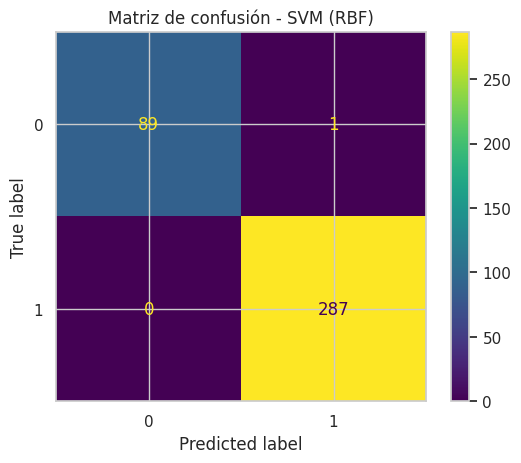

Random Forest: balanced_accuracy train=100.00% | val=95.94%


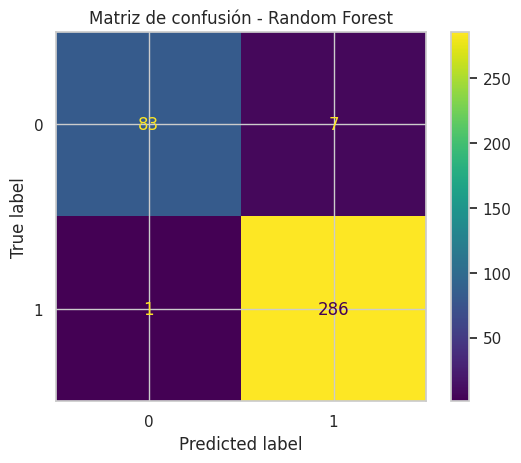

XGBoost: balanced_accuracy train=100.00% | val=97.60%


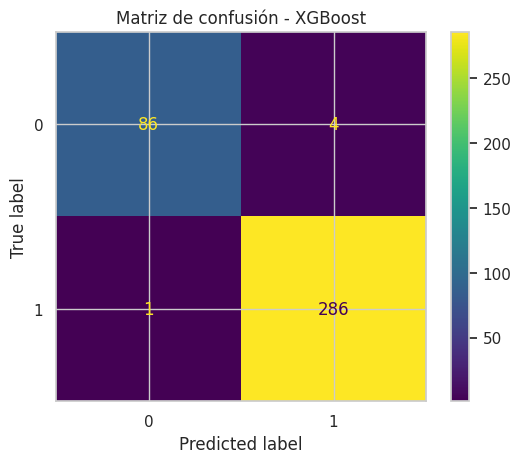

In [59]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

modelos = {
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', random_state=8),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=8),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=8),
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(x_train, y_train)
    pred_train = modelo.predict(x_train)
    pred_val = modelo.predict(x_val)

    ba_train = balanced_accuracy_score(y_train, pred_train)
    ba_val = balanced_accuracy_score(y_val, pred_val)

    resultados[nombre] = {'train': ba_train, 'val': ba_val}
    print(f"{nombre}: balanced_accuracy train={ba_train*100:.2f}% | val={ba_val*100:.2f}%")

    ConfusionMatrixDisplay.from_predictions(y_val, pred_val)
    plt.title(f'Matriz de confusión - {nombre}')
    plt.show()

Las matrices de confusión sobre el conjunto de validación, muestran que SVM (RBF) es el único de los tres sin ningún falso negativo, clasifica las 287 y caras ccb  (100% recall en esa clase) y solo confunde confunde 1 de las 90 caras csb (98.9% de recall), dando el balanced accuracy más alto.

Random Forest es el que más se equivoca en clase minoritaria, en 7 de los 90 casos csb (recall 92.2%) aunque acierta 286 de 287 en ccb, de ahí su balanced_ accuracy más bajo (95.94%).

XGBoost queda en un punto intermedio, 4 errores en csb (recall 95.5%) y 1 en ccb (recall 99.65%) con balanced_accuracy de 97.6%.

Los tres modelos aciertan la clase mayoritaria (ccb), pero se diferencias en cómo manejan la clase minoritatia.


In [60]:
#Validación cruzada
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

resultados_cv = []
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_scaled, y, cv=cv, scoring='balanced_accuracy')
    print(f"{nombre}: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%) | folds: {np.round(scores*100,2)}")
    resultados_cv.append({
        'Modelo': nombre,
        'Media (%)': scores.mean()*100,
        'Desvío (%)': scores.std()*100,
        'Mínimo (%)': scores.min()*100,
        'Máximo (%)': scores.max()*100,
    })

tabla_cv = pd.DataFrame(resultados_cv).sort_values('Media (%)', ascending=False).reset_index(drop=True)
tabla_cv.round(2)

SVM (RBF): 98.60% (+/- 0.53%) | folds: [98.14 99.44 98.89 98.54 97.97]
Random Forest: 95.00% (+/- 1.20%) | folds: [96.84 95.56 93.54 95.21 93.86]
XGBoost: 96.76% (+/- 0.92%) | folds: [97.41 97.05 95.03 97.64 96.67]


,Modelo,Media (%),Desvío (%),Mínimo (%),Máximo (%)
0,SVM (RBF),98.60,0.53,97.97,99.44
1,XGBoost,96.76,0.92,95.03,97.64
2,Random Forest,95.00,1.20,93.54,96.84


Con los resultados se confirma el patrón visto en el split simple, con SVM que es el más preciso en promedio y con menor desvío estándar, seguido pro XGBoost y por último Random Forest que es el más inconsistente entre folds.

In [61]:
# Comparación con el baseline
from sklearn.tree import DecisionTreeClassifier

baseline_clf = DecisionTreeClassifier(random_state=8)
baseline_scores = cross_val_score(baseline_clf, X_scaled, y, cv=cv, scoring='balanced_accuracy')
print(f"Baseline (Árbol de decisión simple): {baseline_scores.mean()*100:.2f}% (+/- {baseline_scores.std()*100:.2f}%)")

mejor_score_svm = tabla_cv[tabla_cv['Modelo']=='SVM (RBF)']['Media (%)'].values[0]
print(f"Tu mejor modelo (SVM, sin tunear todavía): {mejor_score_svm:.2f}%")
print(f"Mejora: +{mejor_score_svm - baseline_scores.mean()*100:.2f} puntos")

Baseline (Árbol de decisión simple): 93.25% (+/- 0.80%)
Tu mejor modelo (SVM, sin tunear todavía): 98.60%
Mejora: +5.35 puntos


Se calculó el balanced_accuracy del modelo baseline de la consigna bajo el mismo esquema de validación cruzada de 5 folds, 93.25% (± 0.80%). Comparado con los 3 modelos probados, incluso sin ajustar hiperparámetros, los tres superan ampliamente este baseline: SVM (98.60%, +5.35 puntos), XGBoost (96.76%, +3.51 puntos) y Random Forest (95.00%, +1.75 puntos).

Esto confirma que las técnicas exploradas (kernels no lineales, ensambles de árboles con bagging y boosting) capturan mejor la estructura del vector de 434 features de la ResNet que un único árbol de decisión, que tiende a sobreajustarse y generalizar peor sobre la clase minoritaria.

A continuación, se realiza el ajuste de hiperparámetros de los 3 modelos para intentar mejorar aún más estos resultados.

In [62]:
# Ajuste de hiperparámetros SVM
from sklearn.model_selection import RandomizedSearchCV

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid_svm = RandomizedSearchCV(
    SVC(class_weight='balanced', random_state=8),
    param_grid_svm,
    n_iter=8,
    scoring='balanced_accuracy',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=10),
    n_jobs=-1,
    random_state=8
)
grid_svm.fit(X_scaled, y)

print("Mejores parámetros SVM:", grid_svm.best_params_)
print("Mejor balanced_accuracy (CV):", grid_svm.best_score_*100, "%")



Mejores parámetros SVM: {'kernel': 'rbf', 'gamma': 0.001, 'C': 100}
Mejor balanced_accuracy (CV): 98.73769028920528 %


In [63]:
#Ajuste de hiperparámetros XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=8),
    param_grid_xgb,
    n_iter=8,
    scoring='balanced_accuracy',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=10),
    n_jobs=-1,
    random_state=8
)
grid_xgb.fit(X_scaled, y)

print("Mejores parámetros XGBoost:", grid_xgb.best_params_)
print("Mejor balanced_accuracy (CV):", grid_xgb.best_score_*100, "%")

Mejores parámetros XGBoost: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Mejor balanced_accuracy (CV): 97.00863128875739 %


In [64]:
#Ajuste Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 5]
}

grid_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=8),
    param_grid_rf,
    n_iter=8,
    scoring='balanced_accuracy',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=10),
    n_jobs=-1,
    random_state=8
)
grid_rf.fit(X_scaled, y)

print("Mejores parámetros Random Forest:", grid_rf.best_params_)
print("Mejor balanced_accuracy (CV):", grid_rf.best_score_*100, "%")

Mejores parámetros Random Forest: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': None}
Mejor balanced_accuracy (CV): 95.97152664880531 %


El ajuste de hiperparámetros mejora levemente los 3 modelos, SVM pasa de 98.6% a 98.74%, XGBoost de 96.76% a 97.01% y Random Forest de 95% a 95.97%. El SVM sigue siendo la mejor opción.

In [65]:
tabla_final = pd.DataFrame([
    {'Modelo': 'SVM (RBF)', 'Balanced Acc. (CV tuneado)': grid_svm.best_score_*100, 'Mejores params': grid_svm.best_params_},
    {'Modelo': 'XGBoost', 'Balanced Acc. (CV tuneado)': grid_xgb.best_score_*100, 'Mejores params': grid_xgb.best_params_},
    {'Modelo': 'Random Forest', 'Balanced Acc. (CV tuneado)': grid_rf.best_score_*100, 'Mejores params': grid_rf.best_params_},
]).sort_values('Balanced Acc. (CV tuneado)', ascending=False).reset_index(drop=True)

tabla_final.round(2)

,Modelo,Balanced Acc. (CV tuneado),Mejores params
0,SVM (RBF),98.74,"{'kernel': 'rbf', 'gamma': 0.001, 'C': 100}"
1,XGBoost,97.01,"{'n_estimators': 200, 'max_depth': 3, 'learnin..."
2,Random Forest,95.97,"{'n_estimators': 200, 'min_samples_leaf': 5, '..."


La tabla presenta la comparación final, en la SVM es el modelo elegido para la predicción final.

In [66]:
# Predicción final
# Se reeentrena el mejor SVM con todos los datos del train
mejor_svm = SVC(**grid_svm.best_params_, class_weight='balanced', random_state=8)
mejor_svm.fit(X_scaled, y)

# Predecimos sobre test
test_pred = mejor_svm.predict(X_test_scaled)

print("Cantidad de predicciones:", len(test_pred))
print("Distribución de la predicción:", pd.Series(test_pred).value_counts())

Cantidad de predicciones: 524
Distribución de la predicción: 1    370
0    154
Name: count, dtype: int64


In [67]:
# Se arma el submission.csv con el mismo formato que sample_submission.csv
submission = pd.DataFrame({
    'id': imagenID_test,
    'clase': test_pred
})

submission.to_csv('submission.csv', header=True, index=False)
submission.head()

,id,clase
0,1,1
1,2,0
2,3,0
3,4,1
4,5,1


In [68]:
# Verificación sin necesitar sample_submission.csv
print("Columnas:", submission.columns.tolist())
print("Shape:", submission.shape)
print("¿Tiene nulos?:", submission.isnull().sum().sum())
print("Valores únicos en 'clase':", submission['clase'].unique())

Columnas: ['id', 'clase']
Shape: (524, 2)
¿Tiene nulos?: 0
Valores únicos en 'clase': [1 0]


In [69]:
# Chequear que no falte ningún id de test
print(set(imagenID_test) == set(submission['id']))

True


El modelo predice 370 caras como ccb (70.6%) y 154 csb (29.4%) sobre el conjunto de test, una proporción cercana a la observada en train (76.2% / 23.8%), lo cual es un buen indicio de que el modelo no está sesgado en una sola clase.

Se verificó que el archivo submission.csv tiene el formato correcto y que incluye todos los IDs del conjunto de test.

### Conclusión Final

Se probaron y compararon 3 modelos (SVM con kernel RBF, Random Forest y XGBoost), evaluados con balanced_accuracy_score mediante validación cruzada estratificada de 5 folds, dado el desbalance de clases detectado en el EDA (76.2% ccb / 23.8% csb). Esta métrica es la adecuada para este problema porque pondera el recall de ambas clases por igual, evitando que un modelo trivial (que prediga siempre la clase mayoritaria) obtenga un score artificialmente alto.

| Modelo | Balanced Acc. (CV, default) | Balanced Acc. (CV, tuneado) |
|---|---|---|
| SVM (RBF) | 98.60% | **98.74%** |
| XGBoost | 96.76% | 97.01% |
| Random Forest | 95.00% | 95.97% |


El SVM con kernel RBF fue elegido como modelo final, obtuvo el mejor balanced_accuracy en los 3 experimentos (default, CV, y tuneado), con el menor desvío estándar entre folds, y el menor gap entre train y validación en el split inicial indicando mejor generalización y menor sobreajuste que Random Forest y XGBoost. Los mejores hiperparámetros encontrados fueron C=100, gamma=0.001, kernel='rbf'.

Durante el EDA se detectaron se detectaron 2 outliers extremos en ch_RGB en el conjunto de test (ids 13 y 269, con valores de 40632 y 16240). En vez de eliminar esas filas, se optó por acotarlos al percentil 99 de ch_RGB calculado sobre train (190.33), aplicando el mismo límite a ambos conjuntos para evitar distorsionar el escalado posterior sin perder información de esas observaciones.

## Demostración

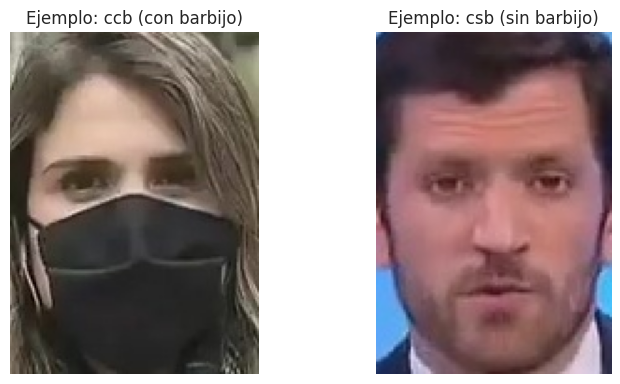

In [70]:
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

url_img1 = "https://raw.githubusercontent.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/Video11-frame-001213_single_box_0.jpg"
url_img2 = "https://raw.githubusercontent.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/Video11-frame-001215_single_box_1.jpg"

img_con_barbijo = Image.open(BytesIO(requests.get(url_img1).content))
img_sin_barbijo = Image.open(BytesIO(requests.get(url_img2).content))

fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(img_con_barbijo)
axes[0].set_title('Ejemplo: ccb (con barbijo)')
axes[0].axis('off')
axes[1].imshow(img_sin_barbijo)
axes[1].set_title('Ejemplo: csb (sin barbijo)')
axes[1].axis('off')
plt.tight_layout()
plt.show()